# Lecture 9 · Non-Maximum Suppression from scratch

**Goal** · implement NMS, run it on a toy set of overlapping detections, and visualise before/after. NMS removes duplicate boxes that fire on the same object.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## 1 · The algorithm

1. sort boxes by score; 2. keep the highest; 3. drop any box with IoU $>\tau$ against it; 4. repeat.

In [2]:
def iou(a, b):
    ix0, iy0 = max(a[0], b[0]), max(a[1], b[1])
    ix1, iy1 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, ix1 - ix0) * max(0, iy1 - iy0)
    ua = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter / ua if ua > 0 else 0.0

def nms(boxes, scores, thresh=0.5):
    order = list(np.argsort(scores)[::-1])   # high score first
    keep = []
    while order:
        i = order.pop(0)
        keep.append(i)
        order = [j for j in order if iou(boxes[i], boxes[j]) <= thresh]
    return keep

## 2 · Toy detections

Three boxes cluster on one object (left) and two on another (right); NMS should keep one per cluster.

In [3]:
boxes = np.array([
    [ 0,  0, 10, 10],   # object 1 cluster
    [ 1,  1, 11, 11],
    [ 2,  0, 12, 10],
    [20,  5, 30, 15],   # object 2 cluster
    [21,  6, 31, 16],
], float)
scores = np.array([0.9, 0.75, 0.8, 0.95, 0.6])
keep = nms(boxes, scores, thresh=0.5)
print('kept box indices:', keep, ' scores:', scores[keep])

kept box indices: [3, 0]  scores: [0.95 0.9 ]


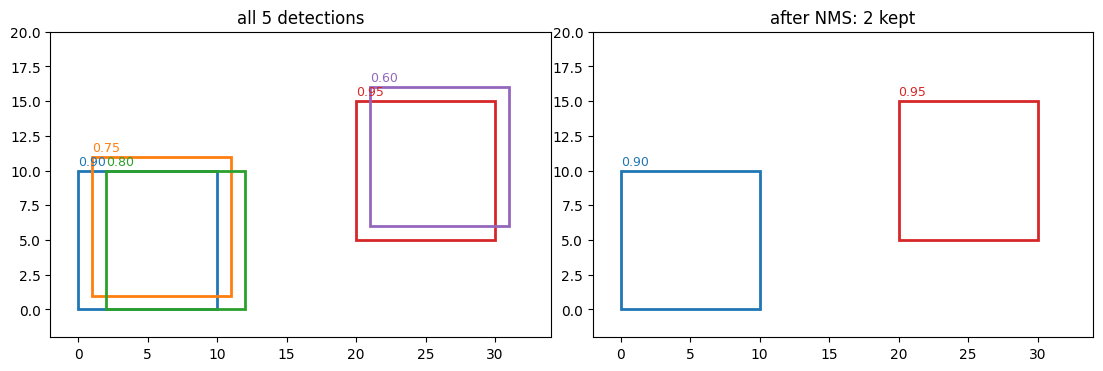

In [4]:
def draw(ax, idxs, title):
    colors = ['C0', 'C1', 'C2', 'C3', 'C4']
    for i in idxs:
        x0, y0, x1, y1 = boxes[i]
        ax.add_patch(mpatches.Rectangle((x0, y0), x1-x0, y1-y0, fill=False, ec=colors[i], lw=2))
        ax.text(x0, y1 + 0.4, f'{scores[i]:.2f}', color=colors[i], fontsize=9)
    ax.set_xlim(-2, 34); ax.set_ylim(-2, 20); ax.set_aspect('equal'); ax.set_title(title)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
draw(ax[0], range(len(boxes)), f'all {len(boxes)} detections')
draw(ax[1], keep, f'after NMS: {len(keep)} kept')
plt.tight_layout(); plt.show()

## Takeaway

- One object usually triggers many overlapping boxes; NMS keeps the highest-scoring one per cluster.
- The IoU threshold $\tau$ trades off duplicate removal vs merging nearby distinct objects.
- NMS is post-processing — no learning, pure geometry on scores + IoU.